c:\Users\juanj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


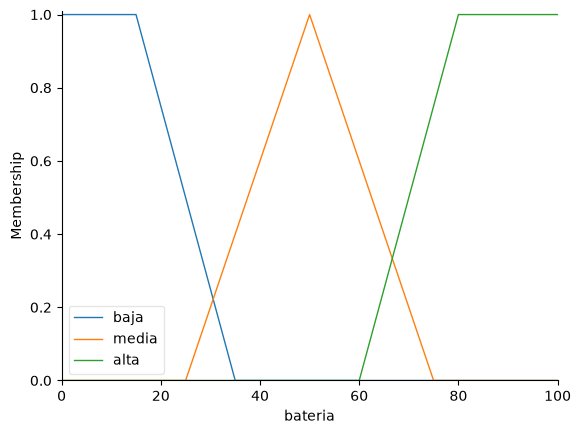

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Todos los valores posibles de batería, de 0% a 100%
bateria = ctrl.Antecedent(np.arange(0, 101, 1), 'bateria')

# Baja: Trapecio con vértices en 0, 0, 15 y 35
bateria['baja']  = fuzz.trapmf(bateria.universe, [0, 0, 15, 35])
# Media: Triangular con vértices en 25, 50 y 75
bateria['media'] = fuzz.trimf(bateria.universe, [25, 50, 75])
# Alta: Trapecio con vértices en 60, 80, 100 y 100
bateria['alta']  = fuzz.trapmf(bateria.universe, [60, 80, 100, 100])

# Dibujar las funciones de pertenencia
bateria.view()
plt.show()

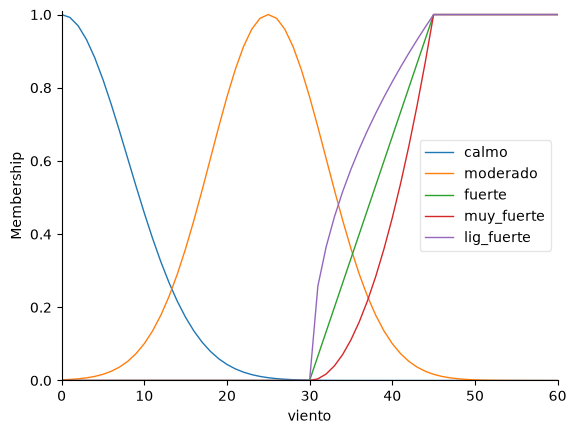

In [2]:
# Todos los valores posibles de viento, de 0 a 60 km/h
viento =  ctrl.Antecedent(np.arange(0, 61, 1), 'viento')

# Calmo: Distribución gaussiana con media 0 y desviación estándar 8
viento['calmo'] = fuzz.gaussmf(viento.universe, 0, 8)
# Moderado: Distribución gaussiana con media 25 y desviación estándar 7
viento['moderado'] = fuzz.gaussmf(viento.universe, 25, 7)
# Fuerte: Trapecio con vértices en 30, 45, 60 y 60
viento['fuerte'] = fuzz.trapmf(viento.universe, [30, 45, 60, 60])

# Modificadores
# Muy fuerte: elevar al cuadrado la función de pertenencia de fuerte
viento['muy_fuerte'] = viento['fuerte'].mf ** 2
# Ligeramente fuerte: raíz cuadrada de la función de pertenencia de fuerte
viento['lig_fuerte'] = np.sqrt(viento['fuerte'].mf)

# Dibujar las funciones de pertenencia
viento.view()
plt.show()

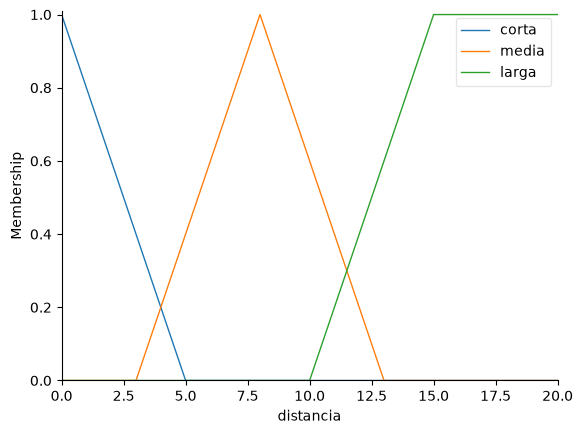

In [3]:
# Todos los valores posibles de distancia, de 0 a 20 km
distancia = ctrl.Antecedent(np.arange(0, 21, 1), 'distancia')

# Corta: Triangular con vértices en 0, 0 y 5
distancia['corta'] = fuzz.trimf(distancia.universe, [0, 0, 5])
# Media: Triangular con vértices en 3, 8 y 13
distancia['media'] = fuzz.trimf(distancia.universe, [3, 8, 13])
# Larga: Trapecio con vértices en 10, 15, 20 y 20
distancia['larga'] = fuzz.trapmf(distancia.universe, [10, 15, 20, 20])

# Dibujar las funciones de pertenencia
distancia.view()
plt.show()

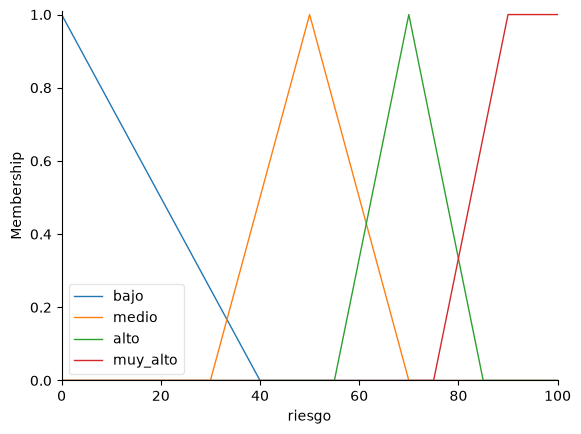

In [4]:
# Todos los valores posibles de riesgo, de 0% a 100%
riesgo = ctrl.Consequent(np.arange(0, 101, 1), 'riesgo')

# Bajo: Triangular con vértices en 0, 0 y 40
riesgo['bajo']     = fuzz.trimf(riesgo.universe, [0, 0, 40])
# Medio: Triangular con vértices en 30, 50 y 70
riesgo['medio']    = fuzz.trimf(riesgo.universe, [30, 50, 70])
# Alto: Triangular con vértices en 55, 70 y 85
riesgo['alto']     = fuzz.trimf(riesgo.universe, [55, 70, 85])
# Muy alto: Trapecio con vértices en 75, 90, 100 y 100
riesgo['muy_alto'] = fuzz.trapmf(riesgo.universe, [75, 90, 100, 100])

# Dibujar las funciones de pertenencia
riesgo.view()
plt.show()

In [5]:
# Reglas

# batería alta & viento calmo & distancia corta → riesgo bajo
regla1 = ctrl.Rule(bateria['alta'] & viento['calmo'] & distancia['corta'], riesgo['bajo'])

# batería baja | viento muy fuerte → riesgo alto
regla2 = ctrl.Rule(bateria['baja'] | viento['muy_fuerte'], riesgo['alto'])

# batería media & distancia media → riesgo medio
regla3 = ctrl.Rule(bateria['media'] & distancia['media'], riesgo['medio'])

# ~batería baja & viento moderado → riesgo medio
regla4 = ctrl.Rule(~bateria['baja'] & viento['moderado'], riesgo['medio'])

# distancia larga & batería media → riesgo alto
regla5 = ctrl.Rule(distancia['larga'] & bateria['media'], riesgo['alto'])

# batería alta & distancia larga & ~viento fuerte → riesgo medio
regla6 = ctrl.Rule(bateria['alta'] & distancia['larga'] & ~viento['fuerte'], riesgo['medio'])

# viento ligeramente fuerte & batería alta → riesgo alto
regla7 = ctrl.Rule(viento['lig_fuerte'] & bateria['alta'], riesgo['alto'])

# batería alta & viento moderado & distancia corta → riesgo bajo
regla8 = ctrl.Rule(bateria['alta'] & viento['moderado'] & distancia['corta'], riesgo['bajo'])

# batería media & viento calmo & distancia corta → riesgo bajo
regla9 = ctrl.Rule(bateria['media'] & viento['calmo'] & distancia['corta'], riesgo['bajo'])

reglas = [regla1, regla2, regla3, regla4, regla5, regla6, regla7, regla8, regla9]

Reglas extra. Fueron necesarias, ya que al momento de probar habían valores sin sentido por falta de reglas claras.

In [6]:
# batería alta & viento calmo & distancia media → riesgo bajo
regla10 = ctrl.Rule(bateria['alta'] & viento['calmo'] & distancia['media'], riesgo['bajo'])

# batería baja & viento fuerte → riesgo muy alto
regla11 = ctrl.Rule(bateria['baja'] & viento['fuerte'], riesgo['muy_alto'])

# batería baja & distancia larga → riesgo muy alto
regla12 = ctrl.Rule(bateria['baja'] & distancia['larga'], riesgo['muy_alto'])

# viento fuerte & (distancia larga | batería media) → riesgo muy alto
regla13 = ctrl.Rule(viento['fuerte'] & (distancia['larga'] | bateria['media']), riesgo['muy_alto'])

# batería baja & ~viento calmo → riesgo muy alto
regla14 = ctrl.Rule(bateria['baja'] & ~viento['calmo'], riesgo['muy_alto'])

for regla in [regla10, regla11, regla12, regla13, regla14]:
    reglas.append(regla)

In [7]:
# Crear el sistema de control difuso
sistema = ctrl.ControlSystem(reglas)

# Crear un "simulador" para darle valores concretos
simulador = ctrl.ControlSystemSimulation(sistema)

67.5164128532562


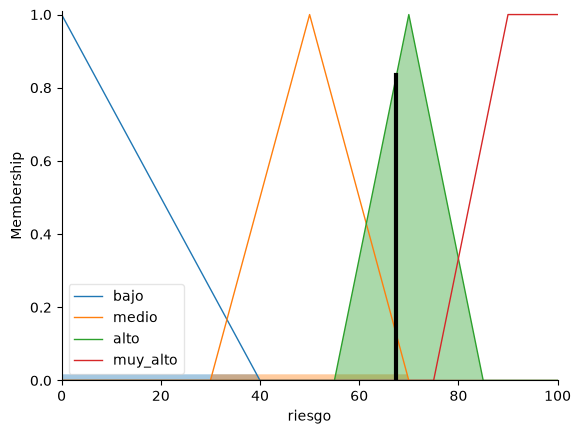

In [8]:
# Darle las entradas
simulador.input['bateria'] = 95
simulador.input['viento'] = 45
simulador.input['distancia'] = 2

# Calcular
simulador.compute()

print(simulador.output['riesgo'])

# Ver la figura agregada y dónde quedó el centroide
riesgo.view(sim=simulador)
plt.show()

In [ ]:
def etiqueta_riesgo(valor):
    """Convierte el riesgo numérico (0-100) en la etiqueta correspondiente."""
    if valor < 35:
        return "bajo"
    elif valor < 60:
        return "medio"
    elif valor < 80:
        return "alto"
    else:
        return "muy_alto"


def calcular_riesgo(bateria_pct, viento_kmh, distancia_km):
    """
    Calcula el riesgo de una misión con el sistema difuso.

    Entradas:
        bateria_pct  -> batería del dron en % (0 a 100)
        viento_kmh   -> velocidad del viento en km/h (0 a 60)
        distancia_km -> distancia de la misión en km (0 a 20)
    Salida:
        (valor, etiqueta), por ejemplo (67.5, "alto")
    """
    # Si llega un valor fuera del universo, lo ajustamos al límite para que el sistema no falle.
    bateria_pct  = float(np.clip(bateria_pct, 0, 100))
    viento_kmh   = float(np.clip(viento_kmh, 0, 60))
    distancia_km = float(np.clip(distancia_km, 0, 20))

    # Cargar las entradas y calcular
    simulador.input['bateria'] = bateria_pct
    simulador.input['viento'] = viento_kmh
    simulador.input['distancia'] = distancia_km

    try:
        simulador.compute()
        valor = round(float(simulador.output['riesgo']), 1)
    except Exception:
        # Si ninguna regla se activara, por seguridad asumimos el peor caso.
        valor = 100.0

    return valor, etiqueta_riesgo(valor)


# Justificación del método de defuzzificación
Para elegir el método de defuzzificación se compararon centroide, bisector y media de máximos en un escenario de viento creciente (batería 50 %, distancia 8 km). La media de máximos resultó inadecuada por dos razones: 
1. Es insensible, porque mantuvo el riesgo en 50 entre 0 y 44.5 km/h e ignoró la contribución de las reglas de viento fuerte.
2. Es inestable, porque un cambio de 0.5 km/h elevó el riesgo de 50 a 89.6, lo que habría pasado de asignar la misión a abortarla.

Se eligió el centroide porque integra el aporte de todas las reglas activadas según su fuerza y produce cambios graduales y proporcionales a las entradas, algo esencial en decisiones de seguridad de vuelo.

In [10]:
from skfuzzy.control.controlsystem import CrispValueCalculator

BATERIA_FIJA = 50     # %
DISTANCIA_FIJA = 8    # km

# Los tres métodos a comparar
METODOS = [
    ('centroid', 'Centroide',        '#2a78d6', '-'),
    ('bisector', 'Bisector',         '#eb6834', '--'),
    ('mom',      'Media de máximos', '#1baf7a', ':'),
]

# Franjas de etiquetas del riesgo
FRANJAS = [(0, 35, 'bajo'), (35, 60, 'medio'), (60, 80, 'alto'), (80, 100, 'muy_alto')]


def salida_agregada(bat, vie, dis):
    sim = ctrl.ControlSystemSimulation(sistema)
    sim.input['bateria'] = bat
    sim.input['viento'] = vie
    sim.input['distancia'] = dis
    sim.compute()
    universo, agregada, _ = CrispValueCalculator(riesgo, sim).find_memberships()
    return universo, agregada


def defuzzificar_todos(bat, vie, dis):
    universo, agregada = salida_agregada(bat, vie, dis)
    return {m: fuzz.defuzz(universo, agregada, m) for m, _, _, _ in METODOS}


def dibujar_franjas(ax, alto_texto):
    for i, (ini, fin, nombre) in enumerate(FRANJAS):
        if i % 2 == 0:
            ax.axvspan(ini, fin, color='#f1f1ee', zorder=0)
        ax.text((ini + fin) / 2, alto_texto, nombre, ha='center', va='bottom',
                fontsize=9, color='#6b6b66')


def dibujar_salida(ax, bat, vie, dis, titulo):
    universo, agregada = salida_agregada(bat, vie, dis)
    dibujar_franjas(ax, 1.08)
    # Términos de salida como referencia (líneas finas grises)
    for nombre, termino in riesgo.terms.items():
        ax.plot(riesgo.universe, termino.mf, color='#c9c9c3', linewidth=1, zorder=1)
    # Figura agregada
    ax.fill_between(universo, 0, agregada, color='#8a8a84', alpha=0.35, zorder=2,
                    label='Salida agregada')
    ax.plot(universo, agregada, color='#5c5c57', linewidth=1.5, zorder=3)
    # Resultado de cada método
    for m, nombre, color, estilo in METODOS:
        valor = fuzz.defuzz(universo, agregada, m)
        ax.axvline(valor, color=color, linestyle=estilo, linewidth=2.2, zorder=4,
                   label=f'{nombre}: {valor:.1f}')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel('Riesgo')
    ax.set_ylabel('Pertenencia')
    ax.set_title(titulo, fontsize=11)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=4,
              fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)


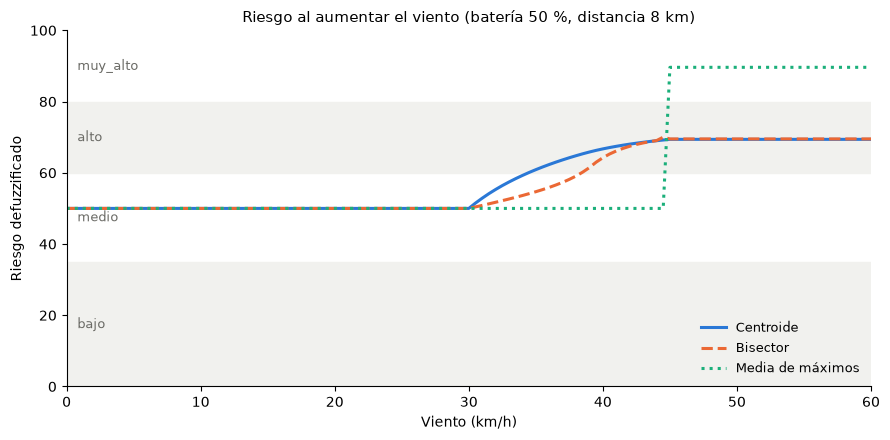

In [11]:
vientos = np.arange(0, 60.5, 0.5)
resultados = {m: [] for m, _, _, _ in METODOS}
for vie in vientos:
    valores = defuzzificar_todos(BATERIA_FIJA, vie, DISTANCIA_FIJA)
    for m in resultados:
        resultados[m].append(valores[m])

fig2, ax = plt.subplots(figsize=(9, 4.5))
for i, (ini, fin, nombre) in enumerate(FRANJAS):      # franjas horizontales
    if i % 2 == 0:
        ax.axhspan(ini, fin, color='#f1f1ee', zorder=0)
    ax.text(0.8, (ini + fin) / 2, nombre, va='center', fontsize=9, color='#6b6b66')
for m, nombre, color, estilo in METODOS:
    ax.plot(vientos, resultados[m], color=color, linestyle=estilo, linewidth=2.2, label=nombre)
ax.set_xlim(0, 60)
ax.set_ylim(0, 100)
ax.set_xlabel('Viento (km/h)')
ax.set_ylabel('Riesgo defuzzificado')
ax.set_title('Riesgo al aumentar el viento (batería 50 %, distancia 8 km)', fontsize=11)
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

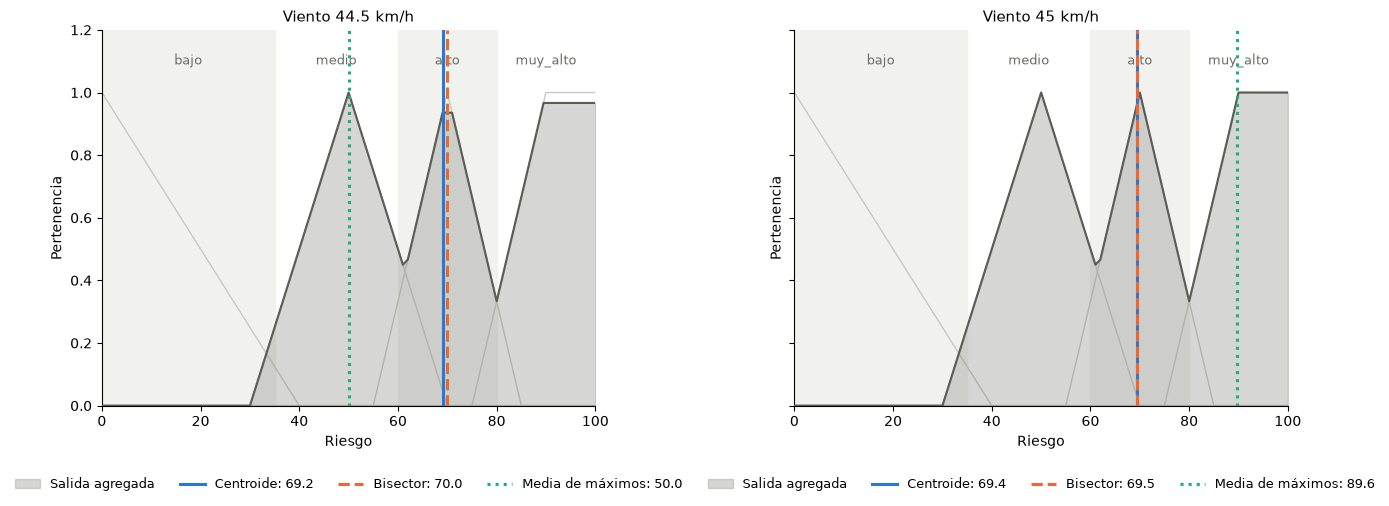

Viento | Centroide | Bisector | Media de máximos
  30.0 |      50.0 |     50.0 |   50.0
  40.0 |      66.7 |     64.2 |   50.0
  44.5 |      69.2 |     70.0 |   50.0
  45.0 |      69.4 |     69.5 |   89.6


In [12]:
fig3, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
dibujar_salida(ax_a, BATERIA_FIJA, 44.5, DISTANCIA_FIJA, 'Viento 44.5 km/h')
dibujar_salida(ax_b, BATERIA_FIJA, 45.0, DISTANCIA_FIJA, 'Viento 45 km/h')
plt.tight_layout()
plt.show()

# Resumen numérico para el documento
print('Viento | Centroide | Bisector | Media de máximos')
for vie in [30, 40, 44.5, 45]:
    val = defuzzificar_todos(BATERIA_FIJA, vie, DISTANCIA_FIJA)
    print(f'{vie:6.1f} | {val["centroid"]:9.1f} | {val["bisector"]:8.1f} | {val["mom"]:6.1f}')